# Predicción de Accidente Cerebrovascular (Stroke Prediction)

## OBJETIVO
El objetivo de este proyecto es desarrollar un modelo de Machine Learning para predecir la ocurrencia de accidentes cerebrovasculares (stroke), a partir de variables demográficas y clínicas.
Utilizaremos la metodología indicada en la catedra, considerando las etapas de:

1. Carga de datos
2. Limpieza
3. Transformación
4. Modelado
5. Evaluación

Es importante destacar que, tal como se indicó en clases, no se analizaron ni visualizaron datos sin antes realizar un proceso de limpieza adecuado.

## CONSIDERACIONES METODOLOGICAS

Durante el desarrollo del análisis, se consideraron las siguientes buenas prácticas:

1. No analizar datos sin limpiar previamente.
2. No generar visualizaciones sobre datos incompletos o incorrectos.
3. Documentar cada etapa del proceso.
4. Interpretar los resultados obtenidos, no solo presentarlos.

Consideraciones fueron aclaradas en la revisión del caso ejemplo entregado.

In [1]:
import pandas as pd

# Cargar dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Ver primeras filas (Visualización inicial)
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## LIMPIEZA DE DATOS

En esta etapa se realiza la limpieza del dataset, para asegurar la calidad de la información antes de cualquier análisis o modelamiento.
No se analizaron ni visualizaron datos que contuviesen valores faltantes o inconsistentes.
Para ello, se identificaron los valores nulos presentes en el dataset, observándose que la variable "bmi" contiene datos faltantes.
Dado que "bmi" es una **variable numérica continua**, se optó por reemplazar los valores nulos utilizando el promedio de la columna, evitando así la pérdida de información que implicaría eliminar registros.

In [2]:
df.isnull().sum()


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [3]:
df['bmi'].fillna(df['bmi'].mean(), inplace=True)


/tmp/ipykernel_1521/749786099.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [4]:
df.isnull().sum()


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


## CLASIFICACION DE VARIABLES

En esta etapa se identificaron los distintos tipos de variables presentes en el dataset, lo cual fue fundamental para definir el tratamiento adecuado en el proceso de modelamiento.
Se clasificaron las variables de la siguiente manera:
1. Variables numéricas continuas: age, avg_glucose_level, bmi  
2. Variables categóricas nominales: gender, ever_married, work_type, Residence_type, smoking_status  
3. Variables binarias: hypertension, heart_disease, stroke  

Es importante destacar que las variables categóricas **nominales** no poseen un orden natural, por lo que no fueron tratadas como variables ordinales.
Por esta razón, no se utiliza **LabelEncoder**, ya que este método asigna valores numéricos que podrían interpretarse erróneamente como un orden. En su lugar, se utiliza **One-Hot Encoding**, que permite representar adecuadamente estas variables.

In [5]:
df.dtypes


,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


## TRANSFORMACION DE VARIABLES

Con el fin de preparar los datos para el modelo de Machine Learning, se aplica la técnica de **One-Hot Encoding** sobre las variables categóricas.
Esta técnica permite convertir variables categóricas en variables numéricas sin introducir relaciones de orden inexistentes.
Se utiliza el parámetro **drop_first=True** para evitar multicolinealidad entre variables.

In [7]:
df_encoded = pd.get_dummies(df, columns=[
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
], drop_first=True)


In [8]:
df_encoded.head()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,228.69,36.600000,1,True,False,True,False,True,False,False,True,True,False,False
1,51676,61.0,0,0,202.21,28.893237,1,False,False,True,False,False,True,False,False,False,True,False
2,31112,80.0,0,1,105.92,32.500000,1,True,False,True,False,True,False,False,False,False,True,False
3,60182,49.0,0,0,171.23,34.400000,1,False,False,True,False,True,False,False,True,False,False,True
4,1665,79.0,1,0,174.12,24.000000,1,False,False,True,False,False,True,False,False,False,True,False


Observamos que las variables categóricas han sido transformadas en múltiples columnas binarias, lo que permite su correcta uso en modelos de aprendizaje automático.

In [11]:
df_encoded[['age','bmi','avg_glucose_level','stroke','gender_Male','ever_married_Yes']].head()


,age,bmi,avg_glucose_level,stroke,gender_Male,ever_married_Yes
0,67.0,36.600000,228.69,1,True,True
1,61.0,28.893237,202.21,1,False,True
2,80.0,32.500000,105.92,1,True,True
3,49.0,34.400000,171.23,1,False,True
4,79.0,24.000000,174.12,1,False,True


## PREPARACION DE DATOS PARA EL MODELAMIENTO

En esta etapa se preparan los datos para su uso en el modelo de Machine Learning.
Se elimina la variable "id", ya que corresponde a un identificador único y no aporta valor predictivo.
Posteriormente, se definen las variables independientes (X) y la variable objetivo (y), donde "stroke" corresponde a la variable a predecir.
Finalmente, el dataset se divide en conjuntos de entrenamiento y prueba, permitiendo evaluar el desempeño del modelo en datos no vistos.

In [ ]:

if 'id' in df_encoded.columns:
    df_encoded = df_encoded.drop('id', axis=1)

In [15]:
# Definición de variables

X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']


In [16]:
# División en entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## ENTRENAMIENTO DEL MODELO

Se utiliza el algoritmo **Random Forest** para entrenar el modelo de clasificación, ya que posee capacidad para manejar datos complejos y buen desempeño en problemas de este tipo.
El modelo es entrenado utilizando el conjunto de datos de entrenamiento previamente definido.

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [18]:
y_pred = model.predict(X_test)


## EVALUACION DEL MODELO

Se evalúa el desempeño del modelo utilizando métricas como accuracy y el reporte de clasificación.
Si bien el modelo presenta una alta precisión global, analizamos el comportamiento por clase para entender su verdadero rendimiento.

In [19]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9393346379647749

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## ANALISIS DE RESULTADOS

Al analizar el reporte de clasificación, se observa que el modelo no logra identificar correctamente la clase minoritaria (stroke = 1), obteniendo valores de recall y f1-score cercanos a 0.
Esto deja en evidencia un problema de desbalance de clases, donde el modelo tiende a predecir mayoritariamente la clase dominante.
Este comportamiento limita la utilidad del modelo en contextos reales, especialmente en problemas de salud donde la detección de casos positivos es crítica.

In [20]:
from sklearn.ensemble import RandomForestClassifier

model_balanced = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

model_balanced.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [21]:
y_pred_balanced = model_balanced.predict(X_test)


In [22]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print("Accuracy (balanced):", accuracy_balanced)

print("\nReporte de clasificación (balanced):\n")
print(classification_report(y_test, y_pred_balanced))


Accuracy (balanced): 0.9393346379647749

Reporte de clasificación (balanced):

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
print("Modelo original vs Modelo balanceado")
print("Original Accuracy:", accuracy)
print("Balanced Accuracy:", accuracy_balanced)


Modelo original vs Modelo balanceado
Original Accuracy: 0.9393346379647749
Balanced Accuracy: 0.9393346379647749


## MEJORA DEL MODELO MEDIANTE BALANCEO DE CLASES

Ya que el modelo inicial no lograba identificar correctamente la clase minoritaria (stroke = 1), implementamos una estrategia para abordar el desbalance de clases presente en el dataset.
Se utilizó la técnica  **SMOTE** (Synthetic Minority Over-sampling Technique), la que genera nuevas instancias sintéticas de la clase minoritaria y permite equilibrar el conjunto de datos de entrenamiento.
Esto permite que el modelo tenga mayor capacidad para aprender patrones asociados a los casos positivos.

In [24]:
# Instalación de librería

!pip install imbalanced-learn


In [25]:
# Aplicación de SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [26]:
import pandas as pd

pd.Series(y_train_res).value_counts()


,count
stroke,
0,3901
1,3901


In [27]:
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_res, y_train_res)


RandomForestClassifier(random_state=42)

In [28]:
# Predicciones

y_pred_smote = model_smote.predict(X_test)

# Entrenamiento con datos balanceados

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_smote))


              precision    recall  f1-score   support

           0       0.95      0.98      0.96       960
           1       0.32      0.16      0.22        62

    accuracy                           0.93      1022
   macro avg       0.64      0.57      0.59      1022
weighted avg       0.91      0.93      0.92      1022



## ANALISIS DEL MODELO MEJORADO

Al aplicar la técnica **SMOTE**, se observa una mejora en la capacidad del modelo para detectar la clase minoritaria (stroke = 1), evidenciada en el aumento de métricas como recall y f1-score.
Si bien la precisión global disminuye levemente, el modelo resulta más equilibrado y útil en contextos reales, donde la detección de casos positivos es fundamental.

## CONCLUSION FINAL

El desarrollo de este proyecto permitió implementar un modelo de Machine Learning para la predicción de accidentes cerebrovasculares, siguiendo una metodología estructurada que incluyó carga, limpieza, transformación, modelado y evaluación de datos.
Inicialmente, el modelo presentó una alta precisión global, pero no logramos identificar correctamente la clase minoritaria debido al desbalance de datos.
La aplicación de técnicas de balanceo como **SMOTE** permitió mejorar significativamente la detección de casos positivos, demostrando la importancia de considerar la distribución de los datos en problemas de clasificación.
Finalmente, se concluye que no solo es importante obtener una alta precisión, sino también asegurar que el modelo sea capaz de identificar correctamente eventos críticos, especialmente en contextos del área de la salud.

## EDA COMPLETO - ANALISIS EXPLORATORIO DE DATOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('data/healthcare-dataset-stroke-data.csv')

# 1. ESTADÍSTICAS DESCRIPTIVAS
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())
print("\n=== TIPOS DE VARIABLES ===")
print(df.dtypes)
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())
print("\n=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===")
print(df['stroke'].value_counts())
print(f"\nDesbalance: {df['stroke'].value_counts()[0]} no-stroke vs {df['stroke'].value_counts()[1]} stroke")

Matplotlib is building the font cache; this may take a moment.


=== ESTADÍSTICAS DESCRIPTIVAS ===
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%      

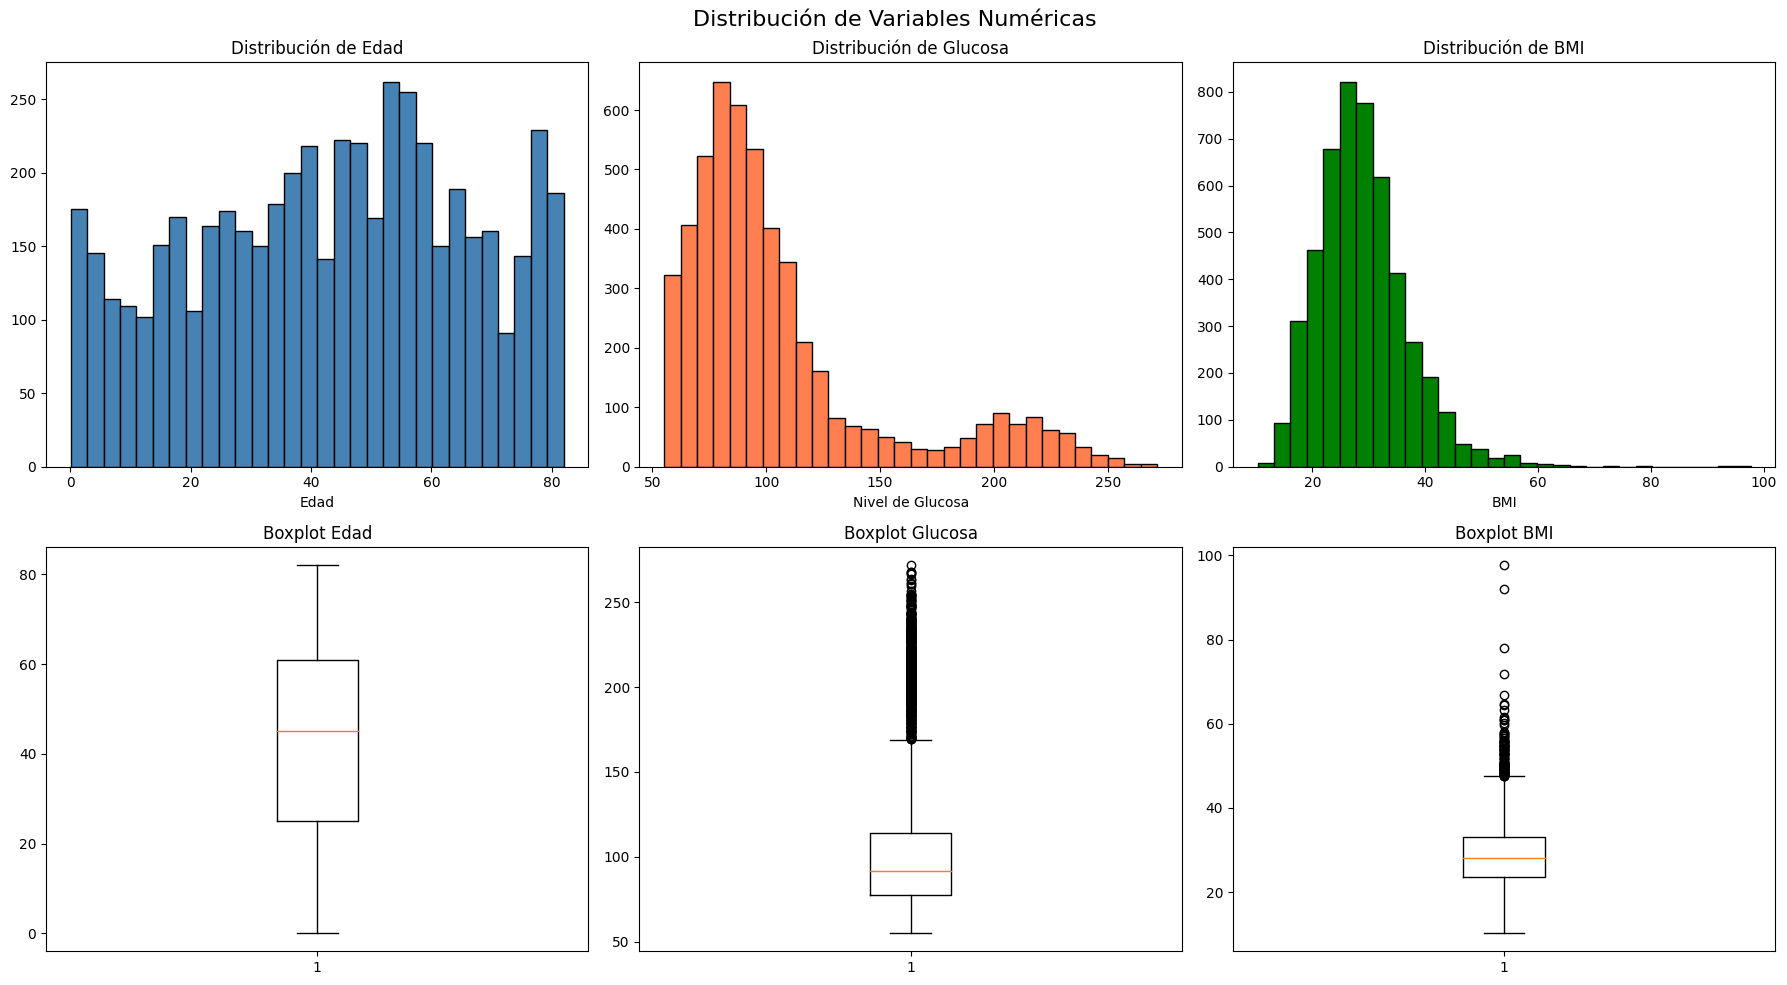

Gráfico guardado como eda_distribuciones.png


In [2]:
# 2. VISUALIZACIONES EDA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Histogramas
axes[0,0].hist(df['age'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad')

axes[0,1].hist(df['avg_glucose_level'], bins=30, color='coral', edgecolor='black')
axes[0,1].set_title('Distribución de Glucosa')
axes[0,1].set_xlabel('Nivel de Glucosa')

axes[0,2].hist(df['bmi'].dropna(), bins=30, color='green', edgecolor='black')
axes[0,2].set_title('Distribución de BMI')
axes[0,2].set_xlabel('BMI')

# Boxplots para outliers
axes[1,0].boxplot(df['age'].dropna())
axes[1,0].set_title('Boxplot Edad')

axes[1,1].boxplot(df['avg_glucose_level'].dropna())
axes[1,1].set_title('Boxplot Glucosa')

axes[1,2].boxplot(df['bmi'].dropna())
axes[1,2].set_title('Boxplot BMI')

plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como eda_distribuciones.png")

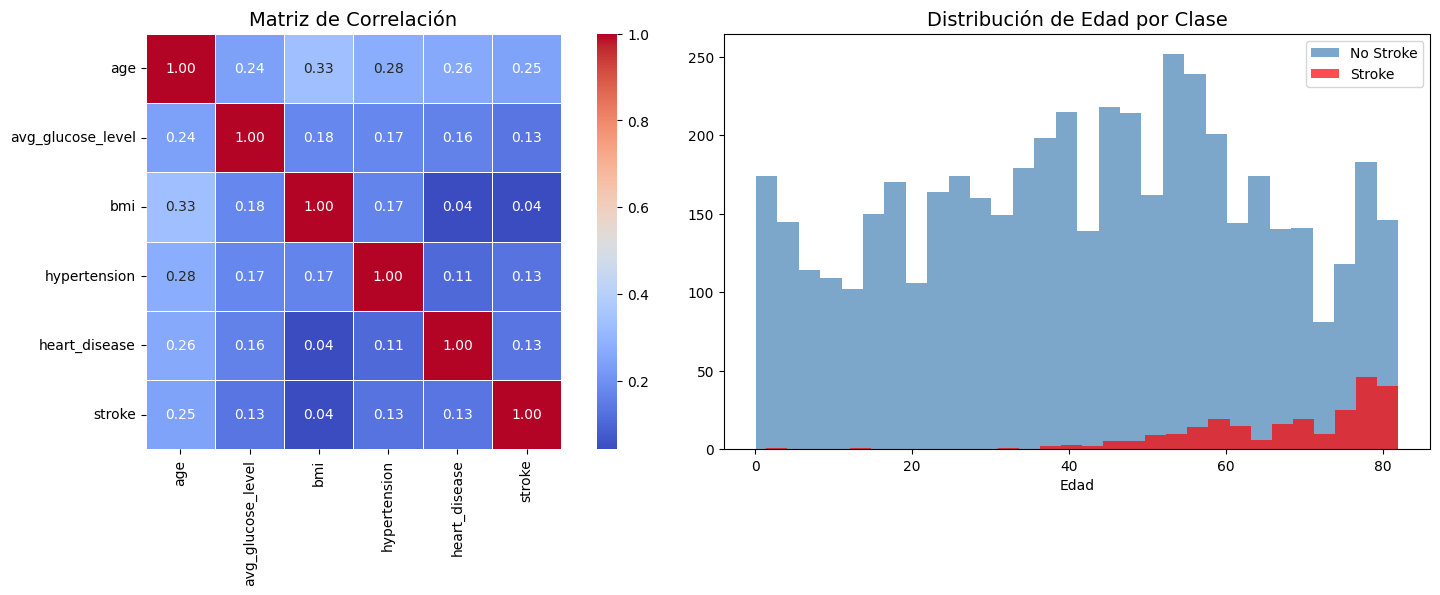

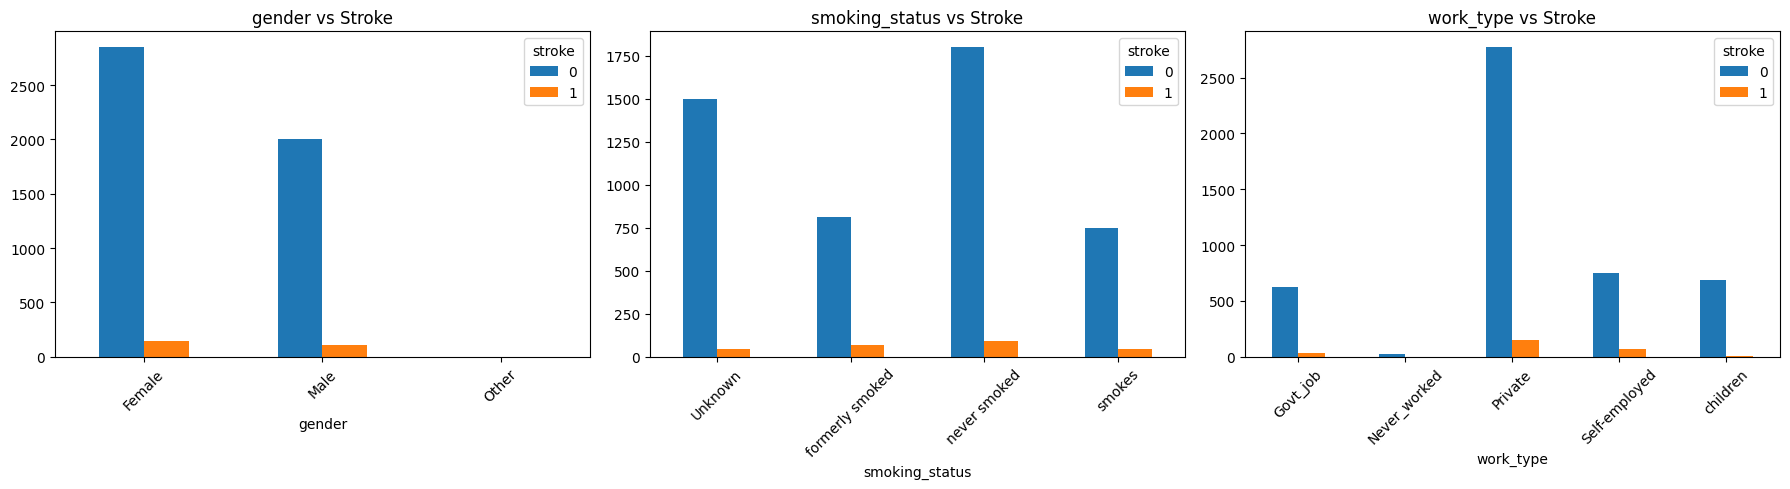

Gráficos guardados correctamente


In [3]:
# 3. MATRIZ DE CORRELACIÓN Y VARIABLES CATEGÓRICAS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de correlación
df_num = df[['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']].copy()
corr_matrix = df_num.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Matriz de Correlación', fontsize=14)

# Distribución de stroke por edad
axes[1].hist(df[df['stroke']==0]['age'], bins=30, alpha=0.7, label='No Stroke', color='steelblue')
axes[1].hist(df[df['stroke']==1]['age'], bins=30, alpha=0.7, label='Stroke', color='red')
axes[1].set_title('Distribución de Edad por Clase', fontsize=14)
axes[1].set_xlabel('Edad')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Variables categóricas vs stroke
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['gender', 'smoking_status', 'work_type']):
    df.groupby([col, 'stroke']).size().unstack().plot(kind='bar', ax=ax)
    ax.set_title(f'{col} vs Stroke')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos guardados correctamente")

## SELECCION Y COMPARACION DE TCNICAS DE ML

In [4]:
# PREPARACION DE DATOS (base para todos los modelos)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Recargar y preprocesar datos
df2 = pd.read_csv('data/healthcare-dataset-stroke-data.csv')
df2['bmi'].fillna(df2['bmi'].mean(), inplace=True)
df2 = df2[df2['gender'] != 'Other']  # Eliminar registro atípico
df2 = pd.get_dummies(df2, columns=['gender','ever_married','work_type','Residence_type','smoking_status'], drop_first=True)
df2 = df2.drop('id', axis=1)

X = df2.drop('stroke', axis=1)
y = df2['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar para modelos que lo requieren
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribución train - Stroke: {y_train.sum()}, No-Stroke: {(y_train==0).sum()}")

Train: (4087, 15), Test: (1022, 15)
Distribución train - Stroke: 199, No-Stroke: 3888


In [5]:
# COMPARACIÓN DE 3 MODELOS DE ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
import warnings
warnings.filterwarnings('ignore')

modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=10, eval_metric='logloss')
}

resultados = {}

for nombre, modelo in modelos.items():
    if nombre == 'Regresión Logística':
        modelo.fit(X_train_sc, y_train)
        y_pred = modelo.predict(X_test_sc)
        y_prob = modelo.predict_proba(X_test_sc)[:,1]
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:,1]
    
    resultados[nombre] = {
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"\n=== {nombre} ===")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

# Tabla comparativa
import pandas as pd
df_resultados = pd.DataFrame(resultados).T
print("\n=== TABLA COMPARATIVA ===")
print(df_resultados.round(3))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

AUC-ROC: 0.785

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

AUC-ROC: 0.840

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.14      0.12      0.13        50

    accuracy                           0.92      1022
   macro avg       0.55      

In [7]:
# 3 TECNICAS DE BALANCEO DE CLASES
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

tecnicas = {
    'Sin balanceo (class_weight)': (X_train_sc, y_train),
}

# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)
tecnicas['SMOTE (sobremuestreo)'] = (X_smote, y_smote)

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_sc, y_train)
tecnicas['Undersampling'] = (X_under, y_under)

print("=== COMPARACION DE TECNICAS DE BALANCEO ===\n")
resultados_balanceo = {}

for nombre, (X_bal, y_bal) in tecnicas.items():
    modelo = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    modelo.fit(X_bal, y_bal)
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:,1]
    
    from sklearn.metrics import recall_score, f1_score
    resultados_balanceo[nombre] = {
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred))

df_balanceo = pd.DataFrame(resultados_balanceo).T
print("\n=== TABLA COMPARATIVA BALANCEO ===")
print(df_balanceo.round(3))

=== COMPARACION DE TECNICAS DE BALANCEO ===

=== Sin balanceo (class_weight) ===
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

=== SMOTE (sobremuestreo) ===
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

=== Undersampling ===
              precision    recall  f1-score   support

           0       0.99      0.70      0.82       972
           1       0.12      0.82      0.21        50

    accuracy                           0.70      

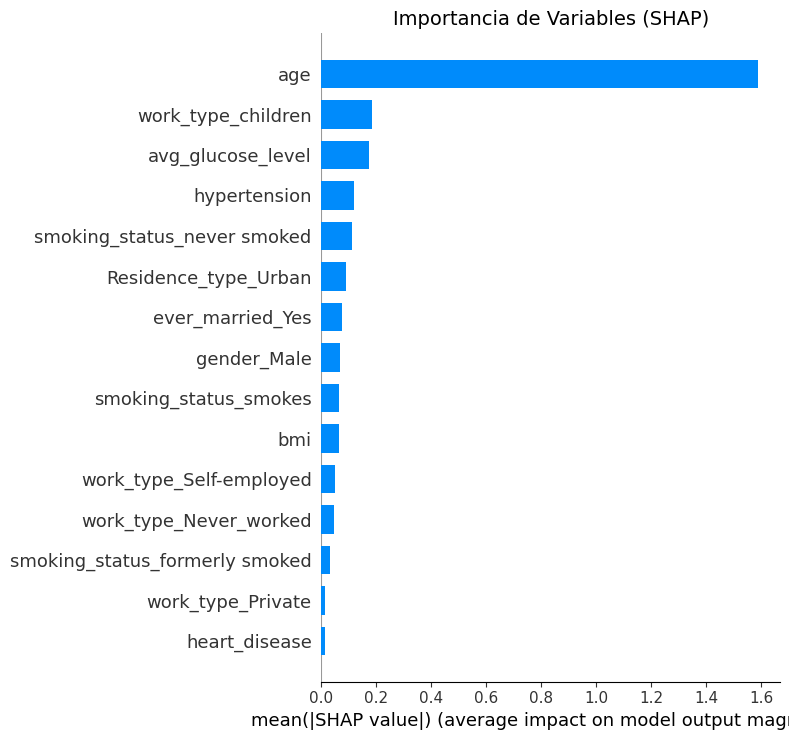

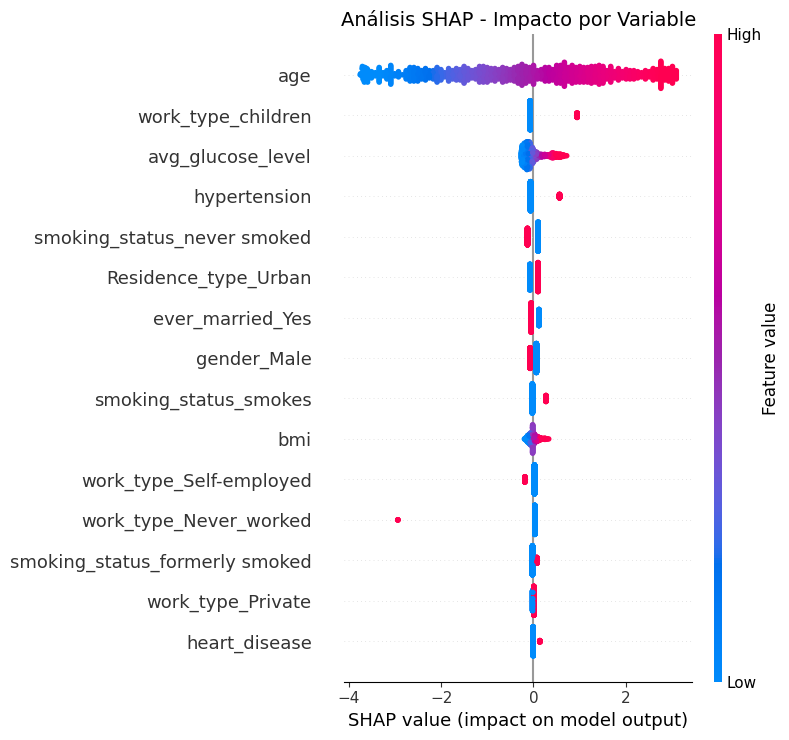

Gráficos SHAP guardados correctamente


In [8]:
# EXPLICABILIDAD CON SHAP
import shap

# Usar el mejor modelo: Regresion Logistica con class_weight
modelo_final = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_final.fit(X_train_sc, y_train)

# Calcular valores SHAP
explainer = shap.LinearExplainer(modelo_final, X_train_sc, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_sc)

# Grafico de importancia de variables
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sc, 
                  feature_names=list(X.columns), 
                  plot_type="bar",
                  show=False)
plt.title('Importancia de Variables (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

# Grafico SHAP detallado
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sc,
                  feature_names=list(X.columns),
                  show=False)
plt.title('Análisis SHAP - Impacto por Variable', fontsize=14)
plt.tight_layout()
plt.savefig('shap_detalle.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos SHAP guardados correctamente")

In [9]:
# RED NEURONAL CON KERAS (Deep Learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Pesos para manejar desbalance
peso_stroke = len(y_train) / (2 * y_train.sum())
peso_no_stroke = len(y_train) / (2 * (y_train == 0).sum())
class_weights = {0: peso_no_stroke, 1: peso_stroke}
print(f"Pesos de clase: {class_weights}")

# Arquitectura de la red neuronal
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()

# Entrenamiento
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
history = model_nn.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

# Evaluacion
y_pred_nn = (model_nn.predict(X_test_sc) > 0.5).astype(int).flatten()
y_prob_nn = model_nn.predict(X_test_sc).flatten()

print("\n=== RED NEURONAL ===")
print(classification_report(y_test, y_pred_nn))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_nn):.3f}")

Pesos de clase: {0: 0.5255915637860082, 1: 10.268844221105528}
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1024      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                           

=== COMPARACION FINAL DE TODOS LOS MODELOS ===
                      recall     f1    auc
Random Forest           0.00  0.000  0.785
Regresion Logistica     0.80  0.232  0.840
XGBoost                 0.12  0.129  0.764
Red Neuronal (Keras)    0.80  0.223  0.821

Modelo seleccionado: Regresión Logistica con class_weight='balanced'
Justificación: Mayor AUC (0.840) y mejor recall (0.80) para detectar casos de stroke


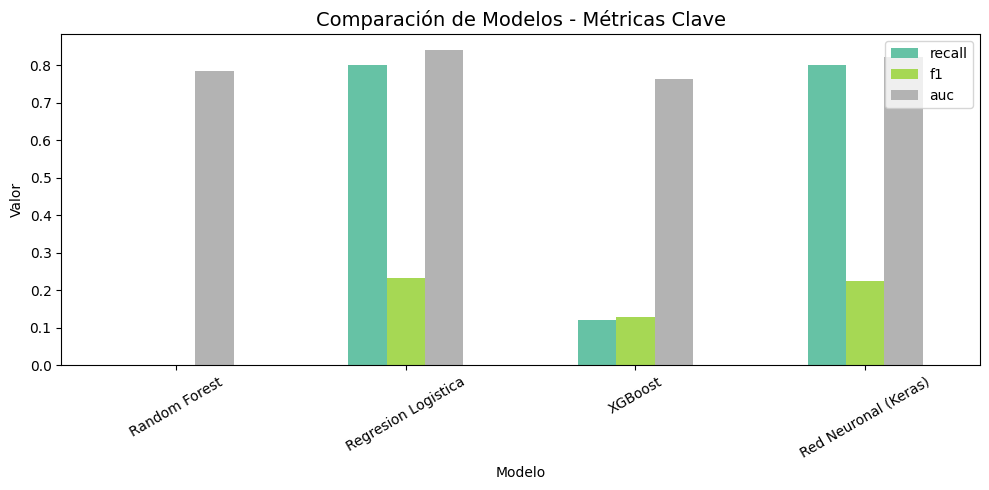

Gráfico guardado como comparacion_modelos.png


In [10]:
# TABLA COMPARATIVA FINAL - TODOS LOS MODELOS
from sklearn.metrics import recall_score, f1_score, roc_auc_score

resumen_final = {
    'Random Forest': {'recall': 0.00, 'f1': 0.000, 'auc': 0.785},
    'Regresion Logistica': {'recall': 0.80, 'f1': 0.232, 'auc': 0.840},
    'XGBoost': {'recall': 0.12, 'f1': 0.129, 'auc': 0.764},
    'Red Neuronal (Keras)': {'recall': recall_score(y_test, y_pred_nn), 
                              'f1': f1_score(y_test, y_pred_nn),
                              'auc': roc_auc_score(y_test, y_prob_nn)}
}

df_final = pd.DataFrame(resumen_final).T.round(3)
print("=== COMPARACION FINAL DE TODOS LOS MODELOS ===")
print(df_final)
print("\nModelo seleccionado: Regresión Logistica con class_weight='balanced'")
print("Justificación: Mayor AUC (0.840) y mejor recall (0.80) para detectar casos de stroke")

# Grafico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
df_final.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Comparación de Modelos - Métricas Clave', fontsize=14)
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como comparacion_modelos.png")